# Phase1. Problem Definition:
* Building a deep learning system to classify emails as Phishing and Legitimate using binary text classsification.
* And for now on we will use LSTM as our deep learning model to train our system

# Importing different libraries 

In [1]:
import pandas as pd # This library is for dealing with csvfile and we manipulate data here 
import re # This is for finding patterns in text and removing urls, html tags , digits and special character or replace them
import nltk # I used this library for dealing with natural language
from nltk.corpus import stopwords  # It is  ready library where all the stop words are stored
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
# import matplotlib.pyplot as plt
# import seaborn as sns
# sns.set_style("whitegrid")



[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ok\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ok\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Phase 2. Data Collection
* Choosing a dataset which includes both Phishing and Legitimate emails
* I choose the "CEAS_08" phishing email dataset because  it has (sender, reciever, body , urls). and has more than 39000 emails and has more than 21000 phishing emails and more 17000 legit emials, it is balanced enough for the model to learn from it 

In [2]:
df = pd.read_csv("../dataset/CEAS_08.csv") # This is my main dataset by which i will train my model , 
df

,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1
...,...,...,...,...,...,...,...
39149,CNN Alerts <charlene-detecton@btcmarketing.com>,email1007@gvc.ceas-challenge.cc,"Fri, 08 Aug 2008 10:34:50 -0400",CNN Alerts: My Custom Alert,\n\nCNN Alerts: My Custom Alert\n\n\n\n\n\n\n ...,1,0
39150,CNN Alerts <idgetily1971@careplusnj.org>,email104@gvc.ceas-challenge.cc,"Fri, 08 Aug 2008 10:35:11 -0400",CNN Alerts: My Custom Alert,\n\nCNN Alerts: My Custom Alert\n\n\n\n\n\n\n ...,1,0
39151,Abhijit Vyas <xpojhbz@gmail.com>,fxgmqwjn@triptracker.net,"Fri, 08 Aug 2008 22:00:43 +0800",Slideshow viewer,Hello there ! \nGreat work on the slide show v...,0,0
39152,Joseph Brennan <vupzesm@columbia.edu>,zqoqi@spamassassin.apache.org,"Fri, 08 Aug 2008 09:00:46 -0500",Note on 2-digit years,"\nMail from sender , coming from intuit.com\ns...",0,0


In [ ]:

# Legitimate emails (label = 0)
legitimate = df[df["label"] == 0].sample(5, random_state=42)

# Phishing emails (label = 1)
phishing = df[df["label"] == 1].sample(5, random_state=42)

print("========== LEGITIMATE EMAILS ==========\n")

for i, row in legitimate.iterrows():
    print(f"Label: {row['label']}")
    print(row["body"])
    print("-" * 80)

print("\n========== PHISHING EMAILS ==========\n")

for i, row in phishing.iterrows():
    print(f"Label: {row['label']}")
    print(row["body"])
    print("-" * 80)

========== LEGITIMATE EMAILS ==========

Label: 0
Hi Everybody,
my squirrelmail version is  squirrelmail-1.4.13  i can't translate the
INBOX.Sent, INBOX.Drafts and INBOX.Trash  found the left frame of the main
window.  everything is translated except those words and they are not
included in the squirrelmail.pot also. i have tried to include in my
translation strings still the result is the same. please please help me.

Thanks in advance,

Helen

--------------------------------------------------------------------------------
Label: 0
Do I understand correctly that with PEP 3102 implemented, keyword
arguments can follow vararg in function definitions, but doing the
same when calling the function is still a syntax error?

With the latest py3k,

>>> def f(a, *args, v=None):
.    pass
.
>>> f(a, *args, v=None)
  File "", line 1
    f(a, *args, v=None)
                ^
SyntaxError: invalid syntax

Is this intentional?
_______________________________________________
Python-3000 mailing list

In [4]:
print(df.loc[ 38969 , "body"])


On Tue, May 6, 2008 at 1:26 PM, Guido van Rossum  wrote:
> On Tue, May 6, 2008 at 12:51 AM, Jeroen Ruigrok van der Werven
>   wrote:
>  > -On [20080505 05:38], Guido van Rossum (hoauf@python.org) wrote:
>  >  >  http://code.google.com/p/rietveld/source/browse
>  >
>  >  Is it a reference to Gerrit Rietveld (Dutch architect and furniture
>  >  designer)?
>
>  Yes, as I explain here:
>  http://code.google.com/p/rietveld/wiki/CodeReviewBackground
>
>
>  > I guess the architect part would make sense for a code review
>  >  tool. :)
>
>  That's purely a coincidence. My dad was an architect and took me on
>  trips of Rietveld's work. I also own some fairly original Zig Zag
>  chairs (much to my family's despair, as they aren't too comfortable.
>  :-)

Was it also a coincidence that Mondrian and Rietveld were both members
of the De Stijl movement? If so, a very nice one!
_______________________________________________
Python-Dev mailing list
zvllln-eum@python.org
http://mail.python.org/mailma

In [5]:

class_counts = df['label'].value_counts()
print("\nLegitimate Emails:", class_counts.get(0, 0))
print("Phishing Emails:", class_counts.get(1, 0))



Legitimate Emails: 17312
Phishing Emails: 21842


In [6]:
print(df.isnull().sum())

sender        0
receiver    462
date          0
subject      28
body          0
label         0
urls          0
dtype: int64


# Phase 3. Data Preprocessing

In [7]:
df['subject'] = df['subject'].fillna("") # Here missing values are replaced by empty strings 
df['body'] = df['body'].fillna("")


In [8]:
df['text'] = df['subject'] + " " + df['body'] # Here both body and subjects are concatenated

In [9]:
print(df[['subject', 'body', 'text']].head())

                                             subject  \
0                          Never agree to be a loser   
1                             Befriend Jenna Jameson   
2                               CNN.com Daily Top 10   
3  Re: svn commit: r619753 - in /spamassassin/tru...   
4                         SpecialPricesPharmMoreinfo   

                                                body  \
0  Buck up, your troubles caused by small dimensi...   
1  \nUpgrade your sex and pleasures with these te...   
2  >+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...   
3  Would anyone object to removing .so from this ...   
4  \nWelcomeFastShippingCustomerSupport\nhttp://7...   

                                                text  
0  Never agree to be a loser Buck up, your troubl...  
1  Befriend Jenna Jameson \nUpgrade your sex and ...  
2  CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...  
3  Re: svn commit: r619753 - in /spamassassin/tru...  
4  SpecialPricesPharmMoreinfo \nWelcomeFastShippi..

In [10]:
df = df[['text','label']].copy()

* Here unwanted and non non word characters are removed 

In [11]:
def clean_text(text):

    text = re.sub(r'\W', ' ', text) # Here i removed any non word character
    text = re.sub(r'http\S+','',text) # Here i replaced urls
    text = re.sub(r'www\S+','', text)
    text = re.sub(r'\d', '', text) # Here the digits were removed from the dataset
    text= text.lower()

    words = text.split()
    clean_words = []
    for word in words:
        if word not in stop_words:
            clean_words.append(word)

    clean_text = " ".join(clean_words)
    return clean_text

In [12]:
df.loc[:,'text'] = df['text'].apply(clean_text) # Here we selected all the rows(emails) of the concatinated dataset and then applied the function which will clean the text(combined data)

* Now here we have the cleaned data, without stopwords, or any unwanted character

In [13]:
print(df['text']) 

0        never agree loser buck troubles caused small d...
1        befriend jenna jameson upgrade sex pleasures t...
2        cnn com daily top daily top cnn com top videos...
3        svn commit r spamassassin trunk lib mail spama...
4        specialpricespharmmoreinfo welcomefastshipping...
                               ...                        
39149    cnn alerts custom alert cnn alerts custom aler...
39150    cnn alerts custom alert cnn alerts custom aler...
39151    slideshow viewer hello great work slide show v...
39152    note digit years mail sender coming intuit com...
39153    python dev pep heads dear fellow pythonistas g...
Name: text, Length: 39154, dtype: object


# Phase 4. Tokenization & Numerical Encoding

In [14]:
from nltk.tokenize import word_tokenize
df['text']

def token_ize(text): # here the text is split into different and indivisual tokens
    return word_tokenize(text)

In [15]:
df['tokens'] = df['text'].apply(token_ize)
print(df['tokens'])  # Here all the words are converted into indivisual tokens

0        [never, agree, loser, buck, troubles, caused, ...
1        [befriend, jenna, jameson, upgrade, sex, pleas...
2        [cnn, com, daily, top, daily, top, cnn, com, t...
3        [svn, commit, r, spamassassin, trunk, lib, mai...
4        [specialpricespharmmoreinfo, welcomefastshippi...
                               ...                        
39149    [cnn, alerts, custom, alert, cnn, alerts, cust...
39150    [cnn, alerts, custom, alert, cnn, alerts, cust...
39151    [slideshow, viewer, hello, great, work, slide,...
39152    [note, digit, years, mail, sender, coming, int...
39153    [python, dev, pep, heads, dear, fellow, python...
Name: tokens, Length: 39154, dtype: object


In [16]:
from collections import Counter 

all_words = []

for tokens in df['tokens']:
    all_words.extend(tokens)

word_counts = Counter(all_words)
len(word_counts)
# type(word_counts)
#  Here we first stored every word of the tokens we created and then added to a list and then counted every word frequency in that list and stored it in another variable 


134961

In [17]:
vocab  = {word: idx+1 for idx, (word, count) in enumerate(word_counts.items())}
len(vocab)
list(vocab.items())[-10:]
# vocab

len(vocab)


134961

* Here is the important step where we converted our text into sequence of integers since our lstm model cannot learn from normal text.

In [18]:
vocab['<UNK>'] = len(vocab) + 1
def numericalize(tokens):
    return [vocab.get(word, vocab['<UNK>']) for word in tokens]
df['sequence'] = df['tokens'].apply(numericalize)
print(df['sequence'])

# import torch

# def text_to_tensor(tokens):
#     sequence = [vocab.get(word, vocab['<UNK>']) for word in tokens]
#     return torch.tensor(sequence)

0        [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...
1             [28, 29, 30, 31, 32, 33, 34, 15, 35, 36, 17]
2        [37, 17, 38, 39, 38, 39, 37, 17, 39, 40, 41, 4...
3        [229, 230, 231, 232, 233, 234, 235, 232, 236, ...
4        [671, 672, 15, 673, 674, 675, 17, 676, 677, 67...
                               ...                        
39149    [37, 1557, 7063, 1528, 37, 1557, 7063, 1528, 1...
39150    [37, 1557, 7063, 1528, 37, 1557, 7063, 1528, 1...
39151    [23411, 23885, 848, 854, 986, 27623, 1856, 238...
39152    [3544, 10360, 1148, 235, 1346, 2365, 40284, 17...
39153    [1804, 2611, 3540, 11255, 1303, 11626, 47553, ...
Name: sequence, Length: 39154, dtype: object


In [19]:
import pickle

with open("../ai_model/saved_models/vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)

print("Vocabulary saved successfully!")

Vocabulary saved successfully!


In [20]:
print(df['tokens'].iloc[12000])
print(df['sequence'].iloc[12000])

['premo', 'narcotic', 'offers', 'perfected', 'substance', 'discounts', 'http', 'anythingcando', 'spaces', 'live', 'com', 'default', 'aspx', 'problems', 'want', 'amelia', 'b', 'las', 'vegas']
[3718, 3719, 4008, 3710, 3711, 3720, 15, 10095, 3666, 2531, 17, 1045, 3667, 1286, 2514, 19564, 323, 2404, 2405]


# Phase 5. Sequence Preparation.
* We give same length to each of the email because the input to neural network should be of same length 

In [21]:
from torch.nn.utils.rnn import pad_sequence
import torch

In [ ]:
max_len = 200 # Here we give maximum lenght of 200 hundreds because there were some emails which length was more than 30000 characters, it makes an outlier and noise in training process and the model cannot learn well from too huge data 

sequences = [torch.tensor(seq[:max_len]) for seq in df['sequence']] 
# print(len(max(df['sequence'])))

padded_sequence = pad_sequence(sequences, batch_first=True)

print(padded_sequence[8900])


# print(padded_sequence.shape)


tensor([ 1591,  1591,  3074,  5109,  6230,  3074,  5109,   280, 15986,   966,
        24172,  6985,  5271,  6985,  5144,  5553,  7716, 12944,  1591, 12944,
         1185,  2254, 56594,  1516,  4043, 10105,  1031,  1591,  2712,    19,
        56595,  3022,  5098, 10884,  1190,  4663, 56595, 47598, 11690, 56595,
         1979,   341,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0, 

* We split our dataset into training and validating  data.
* First we trained our model on the 70% of emails.
* Then we divided the remaining 30% into 15% and 15% indivisually and used the 15 percent for validation and the rest 15 for testing out model 

In [23]:
from sklearn.model_selection import train_test_split

X = padded_sequence
y = torch.tensor(df['label'].values)

# Train 70% | Temp 30%

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state = 42)

# Validation 15%  Test 15%

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

* Then we used the pytorch dataset, it gives the data to the model, how much is asked 

In [24]:
from torch.utils.data import Dataset

class EmailDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx],self.y[idx]

In [25]:
train_dataset = EmailDataset(X_train, y_train)
val_dataset = EmailDataset(X_val, y_val)
test_dataset = EmailDataset(X_test, y_test)

In [26]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=90, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=90)
test_loader = DataLoader(test_dataset, batch_size=90)

In [27]:
for inputs, labels in train_loader:
    print(inputs.shape)
    print(labels.shape)
    break

torch.Size([90, 200])
torch.Size([90])


# Phase 6 . LSTM Architecture Implementation

* In the lstm layer these all operations happen automatically.

* Forget Gate:
f_t = sigmoid(Wf[C_{t-1}, x_t] + bf)

* Input Gate:
 i_t = sigmoid(Wi[h_{t-1}, x_t] + bi)

* Candidate memory:
 C_t = tanh(Wc[h_{t-1}, x_t] + c_t)

* Update Cell:
 C_t = f_t * C_{t-1} + i_t * C_t

* Output Gate:
O_t = sigmoid(Wo[h_{t-1}, x_t]+b0)

* final hidden state:
h_t = o_t * tanh(C_t)

In [28]:
import torch
import torch.nn as nn

class PhishGuardLSTM(nn.Module):
    
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super().__init__()
        
        # Embedding layer
        self.embedding = nn.Embedding(vocab_size + 1, embed_dim)
        self.embedding_dropout = nn.Dropout(0.4)
        
        # LSTM layer
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True,
            
        )
        
        # Dropout before FC layer
        self.fc_dropout = nn.Dropout(0.4)
        
        # Fully connected layer
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        
        # Sigmoid for binary classification
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.embedding(x)
        x = self.embedding_dropout(x)        # ← dropout after embedding

        out, (hidden, cell) = self.lstm(x)

        h_forward = hidden[-2]
        h_backward = hidden[-1]

        h = torch.cat((h_forward, h_backward), dim=1)

        h = self.fc_dropout(h)               # ← dropout before Fully cunnected layer
        out = self.fc(h)

        return self.sigmoid(out)

# Phase 7. Training Setup
* Define Loss Function
* Define Optimizer
* Define Hyperparameters (Learning rate, Epochs, Hidden Size, Embedding Dimensions)

In [29]:
vocab_size = len(vocab)
embed_dim = 32
hidden_dim = 64
output_dim = 1

model = PhishGuardLSTM(vocab_size, embed_dim, hidden_dim, output_dim)

In [30]:


criterion = nn.BCELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

In [32]:
from sklearn.metrics import precision_score

num_epochs = 70

best_val_loss = float('inf')
patience = 20
counter = 0

# Tracking lists
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_precisions = []
val_precisions = []


for epoch in range(num_epochs):
    
    #  TRAINING
    
    model.train()
    train_loss = 0
    
    # Added for tracking 
    all_train_preds = []
    all_train_labels = []
    
    
    for inputs, labels in train_loader:
        
        labels = labels.float().unsqueeze(1)
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        
        loss = criterion(outputs, labels)
        
        loss.backward()
        
        optimizer.step()
        
        train_loss += loss.item()
        
        #Added for tracking 
        predicted = (outputs >= 0.5).float()
        all_train_preds.extend(predicted.squeeze().tolist())
        all_train_labels.extend(labels.squeeze().tolist())
        
    
    train_loss = train_loss / len(train_loader)
    
    #Added for tracking 
    train_acc = sum(p == l for p, l in zip(all_train_preds, all_train_labels)) / len(all_train_labels) * 100
    train_prec = precision_score(all_train_labels, all_train_preds, zero_division=0)
    
    
    
    #VALIDATION
    
    model.eval()
    val_loss = 0
    
    #Added for tracking 
    all_val_preds = []
    all_val_labels = []
    
    
    with torch.no_grad():
        
        for inputs, labels in val_loader:
            
            labels = labels.float().unsqueeze(1)
            
            outputs = model(inputs)
            
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            
            #  Added for tracking 
            predicted = (outputs >= 0.5).float()
            all_val_preds.extend(predicted.squeeze().tolist())
            all_val_labels.extend(labels.squeeze().tolist())
            
    
    val_loss = val_loss / len(val_loader)
    
    # Added for tracking
    val_acc = sum(p == l for p, l in zip(all_val_preds, all_val_labels)) / len(all_val_labels) * 100
    val_prec = precision_score(all_val_labels, all_val_preds, zero_division=0)
    
    
    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")

    print(f"Train Accuracy: {train_acc:.2f}% | Val Accuracy: {val_acc:.2f}%")
    print(f"Train Precision: {train_prec:.4f} | Val Precision: {val_prec:.4f}")
    
    # Added for tracking
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    train_precisions.append(train_prec)
    val_precisions.append(val_prec)
    
    
    #  EARLY STOPPING  
    
    if val_loss < best_val_loss:
        
        best_val_loss = val_loss
        counter = 0
        
        torch.save(model.state_dict(), "../ai_model/saved_models/best_phishguard_model.pth")
        
        print("Model improved, saving...")
    
    else:
        
        counter += 1
        
        print(f"No improvement for {counter} epochs")

    print()
    
    
    if counter >= patience:
        
        print("Early stopping triggered (Model converged)")
        
        break

Epoch 1
Train Loss: 0.3922
Validation Loss: 0.1823
Train Accuracy: 82.26% | Val Accuracy: 93.36%
Train Precision: 0.7969 | Val Precision: 0.9400
Model improved, saving...

Epoch 2
Train Loss: 0.1634
Validation Loss: 0.1283
Train Accuracy: 94.29% | Val Accuracy: 95.78%
Train Precision: 0.9419 | Val Precision: 0.9414
Model improved, saving...

Epoch 3
Train Loss: 0.1092
Validation Loss: 0.0871
Train Accuracy: 96.34% | Val Accuracy: 97.16%
Train Precision: 0.9646 | Val Precision: 0.9610
Model improved, saving...

Epoch 4
Train Loss: 0.0819
Validation Loss: 0.1109
Train Accuracy: 97.34% | Val Accuracy: 96.70%
Train Precision: 0.9735 | Val Precision: 0.9480
No improvement for 1 epochs

Epoch 5
Train Loss: 0.0617
Validation Loss: 0.0725
Train Accuracy: 97.95% | Val Accuracy: 97.58%
Train Precision: 0.9796 | Val Precision: 0.9618
Model improved, saving...

Epoch 6
Train Loss: 0.0490
Validation Loss: 0.0438
Train Accuracy: 98.38% | Val Accuracy: 98.55%
Train Precision: 0.9833 | Val Precision: 

In [33]:
model.load_state_dict(torch.load("../ai_model/saved_models/best_phishguard_model.pth"))


<All keys matched successfully>

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import torch
model.eval()  # Set model to evaluation mode

all_preds = []
all_labels = []

with torch.no_grad():  # Disable gradient calculation
    for inputs, labels in test_loader:
        
        outputs = model(inputs)
        
        preds = (outputs >= 0.5).int()  # Convert probability → 0 or 1
        
        all_preds.extend(preds.squeeze().tolist())
        all_labels.extend(labels.tolist())

# Calculate metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)

Accuracy: 0.9964249233912156
Precision: 0.9972594397076736
Recall: 0.9963492546394889
F1 Score: 0.9968041394003957
Confusion Matrix:
 [[2578    9]
 [  12 3275]]


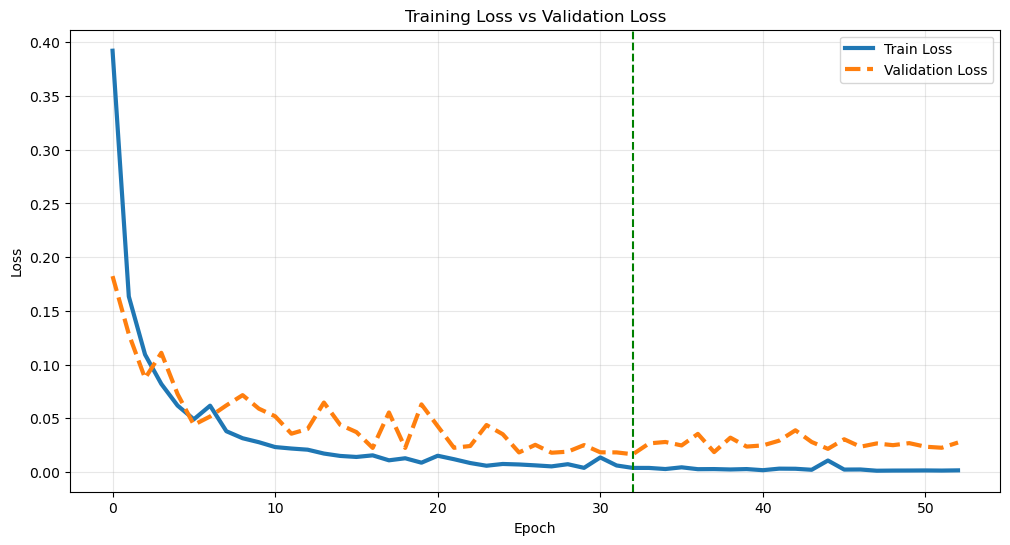

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(train_losses, label='Train Loss', linewidth=3)
plt.plot(val_losses, '--', label='Validation Loss', linewidth=3)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
best_epoch = val_losses.index(min(val_losses))
plt.axvline(
    x=best_epoch,
    color='green',
    linestyle='--',
    label=f'Best Model (Epoch {best_epoch+1})'
)
plt.show()

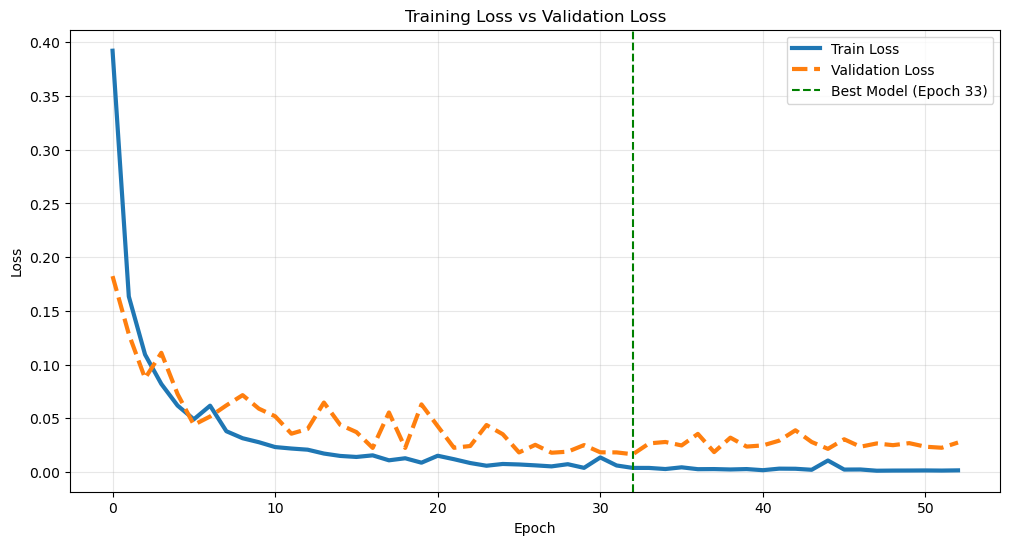

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(train_losses, label='Train Loss', linewidth=3)
plt.plot(val_losses, '--', label='Validation Loss', linewidth=3)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

best_epoch = val_losses.index(min(val_losses))
plt.axvline(
    x=best_epoch,
    color='green',
    linestyle='--',
    label=f'Best Model (Epoch {best_epoch+1})'
)
plt.legend()
plt.show()

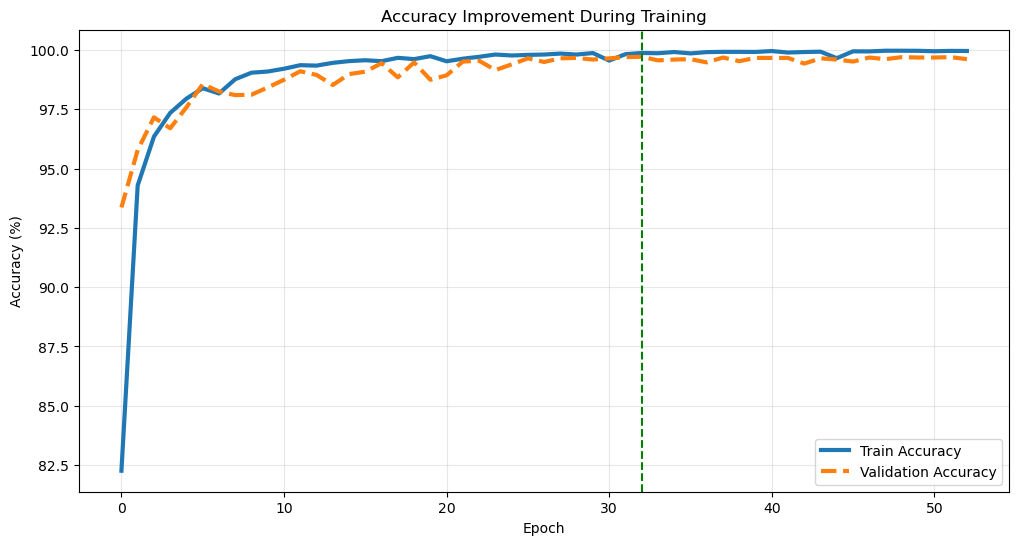

In [37]:
plt.figure(figsize=(12,6))

plt.plot(train_accuracies, label='Train Accuracy', linewidth=3)
plt.plot(val_accuracies, '--', label='Validation Accuracy', linewidth=3)

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Improvement During Training')
plt.legend()
plt.grid(True, alpha=0.3)
best_epoch = val_losses.index(min(val_losses))
plt.axvline(
    x=best_epoch,
    color='green',
    linestyle='--',
    label=f'Best Model (Epoch {best_epoch+1})'
)
plt.show()

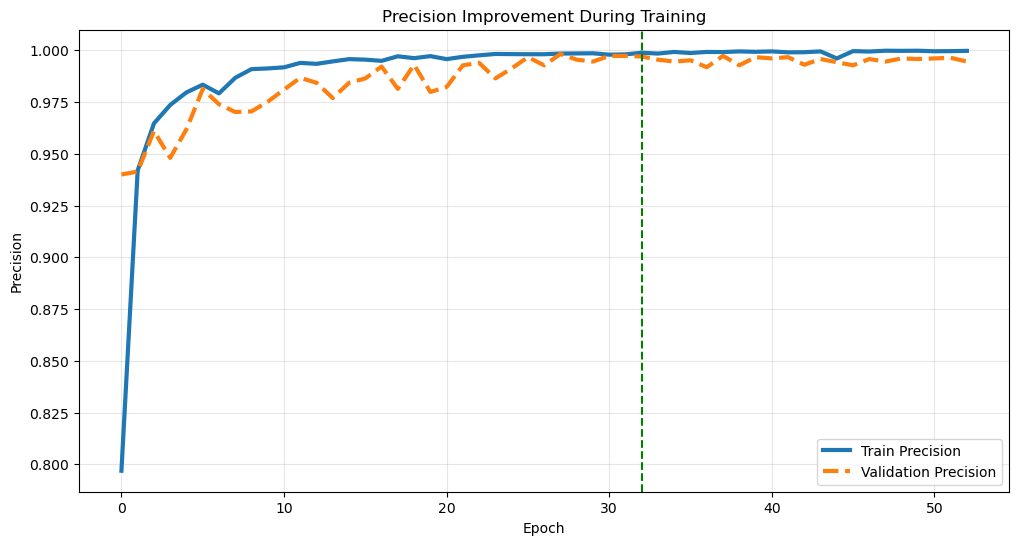

In [38]:
plt.figure(figsize=(12,6))

plt.plot(train_precisions, label='Train Precision', linewidth=3)
plt.plot(val_precisions, '--', label='Validation Precision', linewidth=3)

plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.title('Precision Improvement During Training')
plt.legend()
plt.grid(True, alpha=0.3)

best_epoch = val_losses.index(min(val_losses))
best_epoch = val_losses.index(min(val_losses))
plt.axvline(
    x=best_epoch,
    color='green',
    linestyle='--',
    label=f'Best Model (Epoch {best_epoch+1})'
)
plt.show()

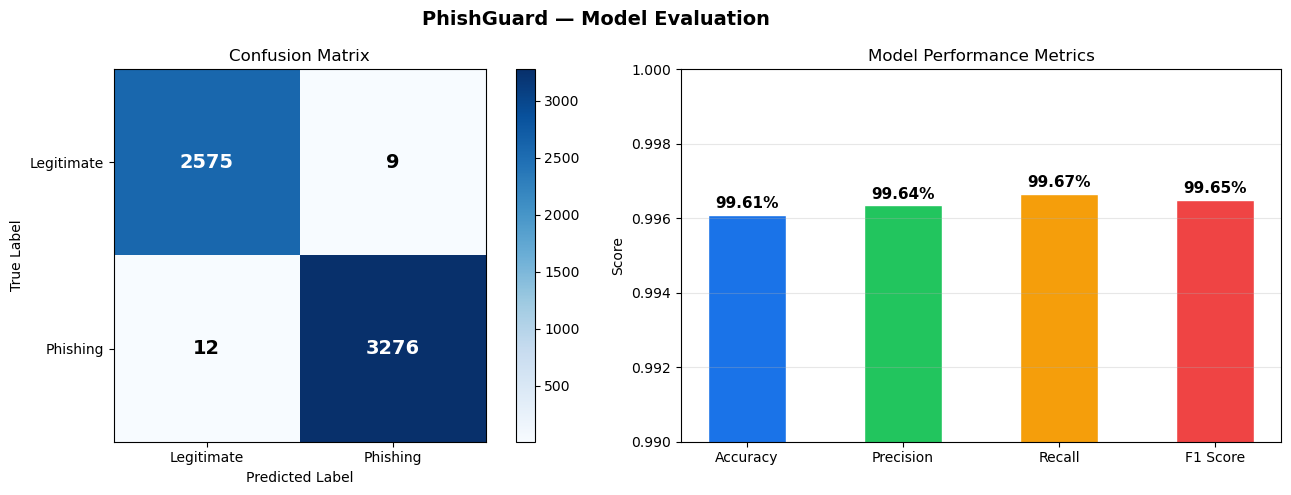

Saved as evaluation_report.png


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix


accuracy  = 0.9960844399046647
precision = 0.9963503649635036
recall    = 0.9966534834195315
f1        = 0.9965019011406844

cm = np.array([[2575, 9],
               [12,   3276]])

# ── Plot ──────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PhishGuard — Model Evaluation', fontsize=14, fontweight='bold')

# Confusion Matrix
im = ax1.imshow(cm, interpolation='nearest', cmap='Blues')
ax1.set_title('Confusion Matrix')
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('True Label')
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(['Legitimate', 'Phishing'])
ax1.set_yticklabels(['Legitimate', 'Phishing'])

for i in range(2):
    for j in range(2):
        ax1.text(j, i, str(cm[i, j]),
                 ha='center', va='center',
                 fontsize=14, fontweight='bold',
                 color='white' if cm[i, j] > 1000 else 'black')

plt.colorbar(im, ax=ax1)

# Metrics Bar Chart
names  = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]
colors = ['#1a73e8', '#22c55e', '#f59e0b', '#ef4444']

bars = ax2.bar(names, values, color=colors,
               width=0.5, edgecolor='white')
ax2.set_title('Model Performance Metrics')
ax2.set_ylabel('Score')
ax2.set_ylim([0.99, 1.0])
ax2.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.0001,
             f'{val * 100:.2f}%',
             ha='center', va='bottom',
             fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('evaluation_report.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved as evaluation_report.png")